In [144]:
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from xgboost import plot_importance
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc, balanced_accuracy_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.under_sampling import RandomUnderSampler





## Load Dataset

In [ ]:
data = pd.read_csv(
    'T49.2_Sep2025_1_StGallen.csv',
    sep=';',
    na_values=["", " ", "NA", "N/A", "NULL"]
)

# commas instead of dots
data = data.replace(",", ".", regex=True)

# Nur Spalten numerisch machen, die wirklich vollständig numerisch sind
for col in data.columns:
    # Wenn alle Werte numerisch interpretierbar sind, dann konvertieren
    temp = pd.to_numeric(data[col], errors="coerce")
    if temp.notna().sum() == len(data[col]):   # ALLE Werte numerisch
        data[col] = temp

# Alles, was wie eine Zahl aussieht, in echte Zahlen umwandeln
data = data.apply(pd.to_numeric, errors='ignore')
display(data)

# Zielvariable abtrennen
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]

/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_83609/3478138819.py:1: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(
/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_83609/3478138819.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')


,OUTCOME_3Kat_KHK,Alter_0,geschlecht,waist_0,WHR_0,BMI_0,currsmo0,RR_syst_0,RR_diast_0,Pulse_Pressure,...,SMC231l,SMC232l,SMC233l,SMC240l,SMC241l,SMC242l,SMC243l,SMC244l,SMC263l,SMC264l
0,2,56.969199,0,112.0,0.982456,32.873110,0,130.0,80.0,50.0,...,9.44,4.38,3.99,14.1,25.8,7.8,3.99,3.99,3.99,3.99
1,2,69.497604,0,104.0,1.040000,30.110279,0,160.0,70.0,90.0,...,19.80,8.97,7.75,21.9,41.3,20.1,7.35,NaN,7.45,8.11
2,2,72.049281,0,129.0,0.941606,44.734880,0,140.0,90.0,50.0,...,13.90,4.75,3.99,20.3,52.4,18.6,3.99,3.99,3.99,3.99
3,2,70.814511,0,99.0,0.876106,26.259585,0,130.0,90.0,40.0,...,20.00,8.73,7.85,25.3,50.7,17.0,0.00,NaN,7.63,9.02
4,2,62.160164,1,125.0,NaN,42.436634,1,180.0,100.0,80.0,...,16.90,9.14,8.30,29.5,43.0,17.9,8.13,0.00,8.40,8.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,0,48.000000,1,94.0,NaN,21.229050,0,115.0,64.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2306,0,68.000000,0,97.0,NaN,28.734694,0,222.0,101.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2307,0,66.220397,0,101.0,0.943925,26.573129,0,135.0,80.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2308,0,65.429158,0,93.0,0.930000,26.769780,0,140.0,80.0,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Preprocessing

In [ ]:
# Drop Dependent Variables
columns_to_drop = [
    "remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol",
    "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"
]
data = data.drop(columns_to_drop, axis=1)

# Manuelle kategoriale Variablen definieren
manual_categorical_candidates = [
    "geschlecht",
    "currsmo0",
    "diabetes_ADA_final_0",
    "ANY_OPE",
    "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]

# In data casten (damit Data Wrangler es sieht)
for col in manual_categorical_candidates:
    if col in data.columns:
        data[col] = data[col].astype(str)

# X/y definieren
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]

# Neue automatische Erkennung der Kategorien
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Numerische Features
numerical_features = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_features = [
    col for col in numerical_features
    if col not in categorical_features
]

print("Kategoriale Features:", len(categorical_features))
print("Numerische Features:", len(numerical_features))


# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Gewichte
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# Preprocessing Pipelines
cat_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pre, categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

display(data)




Kategoriale Features: 7
Numerische Features: 634


,OUTCOME_3Kat_KHK,Alter_0,geschlecht,waist_0,WHR_0,BMI_0,currsmo0,RR_syst_0,RR_diast_0,Pulse_Pressure,...,SMC231l,SMC232l,SMC233l,SMC240l,SMC241l,SMC242l,SMC243l,SMC244l,SMC263l,SMC264l
0,2,56.969199,0,112.0,0.982456,32.873110,0,130.0,80.0,50.0,...,9.44,4.38,3.99,14.1,25.8,7.8,3.99,3.99,3.99,3.99
1,2,69.497604,0,104.0,1.040000,30.110279,0,160.0,70.0,90.0,...,19.80,8.97,7.75,21.9,41.3,20.1,7.35,NaN,7.45,8.11
2,2,72.049281,0,129.0,0.941606,44.734880,0,140.0,90.0,50.0,...,13.90,4.75,3.99,20.3,52.4,18.6,3.99,3.99,3.99,3.99
3,2,70.814511,0,99.0,0.876106,26.259585,0,130.0,90.0,40.0,...,20.00,8.73,7.85,25.3,50.7,17.0,0.00,NaN,7.63,9.02
4,2,62.160164,1,125.0,NaN,42.436634,1,180.0,100.0,80.0,...,16.90,9.14,8.30,29.5,43.0,17.9,8.13,0.00,8.40,8.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,0,48.000000,1,94.0,NaN,21.229050,0,115.0,64.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2306,0,68.000000,0,97.0,NaN,28.734694,0,222.0,101.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2307,0,66.220397,0,101.0,0.943925,26.573129,0,135.0,80.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2308,0,65.429158,0,93.0,0.930000,26.769780,0,140.0,80.0,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Build Pipeline

In [ ]:
pipeline = Pipeline(
   [
       ("preprocessor", preprocessor),
       ("classifier", XGBClassifier(
    tree_method="hist",
    n_estimators=450,
    learning_rate=0.06,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1,
    objective="multi:softprob", 
    num_class=3                   
)),
   ]
)

#CV and training
# Perform 5-fold cross-validation

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)

# Fit the model on the training data
pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Check Overfitting

In [148]:

train_preds = pipeline.predict(X_train)
test_preds = y_pred

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Check for large difference between train and test accuracy
if train_accuracy - test_accuracy > 0.1:
    print("Warning: The model may be overfitting!")

Training Accuracy: 0.9499
Test Accuracy: 0.5325


In [149]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=cv,
    scoring="balanced_accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, marker="o", color="royalblue", label="Train (balanced acc)")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 color="royalblue", alpha=0.2)

plt.plot(train_sizes, val_mean, marker="+", color="seagreen", label="Validation (balanced acc)")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 color="seagreen", alpha=0.2)

plt.title("Learning Curve — Multiclass XGBoost")
plt.xlabel("Training set size")
plt.ylabel("Balanced accuracy")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

# Randomized Search

In [ ]:

from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions
param_dist = {
'classifier__learning_rate': [0.02, 0.03, 0.04, 0.05],
'classifier__max_depth': [5, 6, 7],
'classifier__subsample': [0.8, 0.9, 1.0],
'classifier__colsample_bytree': [0.7, 0.8, 0.9],

}

# Perform random search
random_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_dist, 
    n_iter=200,
    cv=3, 
    n_jobs=-1,  
    verbose=2, 
    random_state=42,
    scoring='balanced_accuracy'
)

random_search.fit(X_train, y_train)

# Print best parameters
print(f"Best parameters: {random_search.best_params_}")
print(f"Best score: {random_search.best_score_}")

# Use best model for predictions
y_pred = random_search.best_estimator_.predict(X_test)

#Best parameters: {'classifier__colsample_bytree': np.float64(0.7433862914177091), 'classifier__learning_rate': np.float64(0.04360202726228762), 'classifier__max_depth': 7, 'classifier__min_child_weight': 1, 'classifier__subsample': np.float64(0.8493192507310232)}
#Best score: 0.5854978354978355

# Best parameters: {'classifier__colsample_bytree': np.float64(0.9341209982356952), 'classifier__learning_rate': np.float64(0.10302621884180338), 'classifier__max_depth': 5, 'classifier__min_child_weight': 1, 'classifier__subsample': np.float64(0.943343521925488)}
# Best score: 0.586038961038961


/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 108 is smaller than n_iter=200. Running 108 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.8; total time=  22.9s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=1.0; total time=  23.0s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=1.0; total time=  24.0s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.9; total time=  24.4s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.9; total time=  25.4s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.9; total time=  25.4s
[CV] END classifier__colsample_bytree=0.7, classifier__learni

Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x115979070>>
Traceback (most recent call last):
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/xgboost/core.py", line 630, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument

KeyboardInterrupt: 
Fatal Python error: Aborted

Current thread 0x00000001eeffa080 (most recent call first):
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py", line 147 in __call__
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/joblib/parallel.py", line 607 in __call__
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-

KeyboardInterrupt: 

# Undersampling Trial

In [ ]:

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import balanced_accuracy_score, classification_report
from xgboost import XGBClassifier # Include this if it wasn't imported earlier

# 1. Define the Undersampling Pipeline
undersample_pipe = ImbPipeline(
   [
       ("preprocessor", preprocessor), # Reuses your existing preprocessor
       ("rus", RandomUnderSampler(sampling_strategy='auto', random_state=42)), # The new step
       ("classifier", XGBClassifier(
            tree_method="hist",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="mlogloss",
            n_jobs=-1
       )),
   ]
)

print("\n--- Training Undersampled Model ---")
# 2. Fit the Model (NO sample_weight needed)
undersample_pipe.fit(X_train, y_train) 

# 3. Predict and Evaluate
y_pred_rus = undersample_pipe.predict(X_test)
y_proba_rus = undersample_pipe.predict_proba(X_test)
balanced_acc_rus = balanced_accuracy_score(y_test, y_pred_rus)

print(f"Balanced Accuracy (Undersampling Model): {balanced_acc_rus:.4f}")

#


--- Training Undersampled Model ---
Balanced Accuracy (Undersampling Model): 0.5070


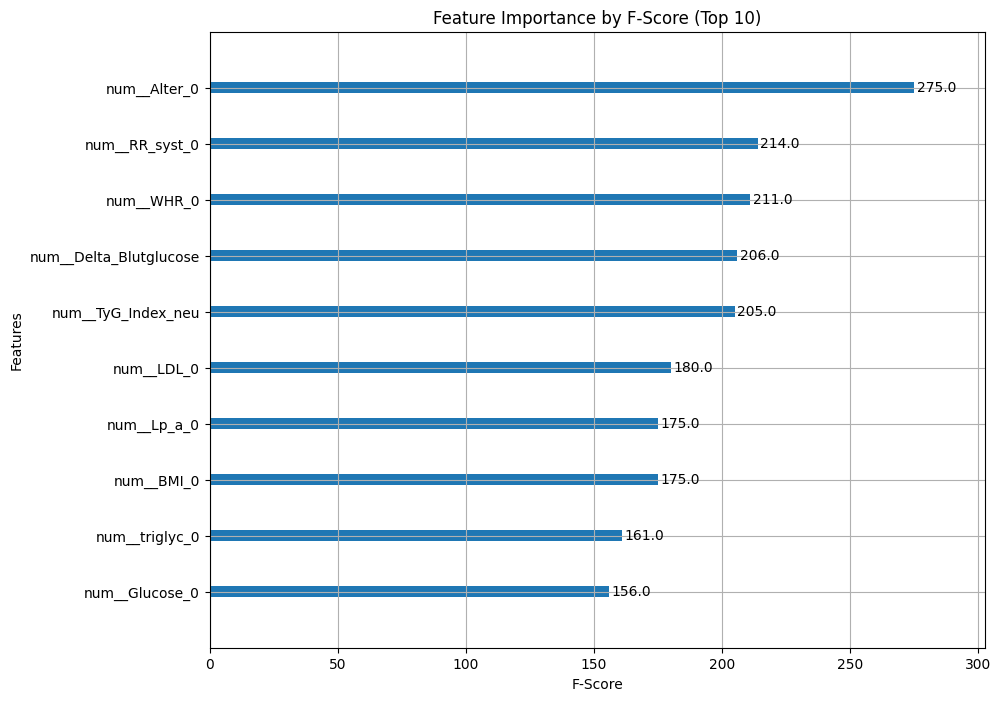

In [150]:
# Find the top 10 important features using XGBoost's plot_importance

# 1. Get the final feature names
feature_names_out = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Extract the trained scikit-learn wrapper
xgb_model = pipeline.named_steps['classifier']

# 3. CRITICAL: Get the underlying Booster object
booster = xgb_model.get_booster()

# 4. CRITICAL: Set the feature names on the Booster object
booster.feature_names = list(feature_names_out)

# 5. Plot the importance using the Booster
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(
    booster,
    ax=ax,
    importance_type='weight',
    xlabel='F-Score',
    max_num_features=10
)
ax.set_title("Feature Importance by F-Score (Top 10)")
plt.show()

# Evaluation

In [151]:

# Baseline evaluation (original pipeline)
baseline_bal_acc = balanced_accuracy_score(y_test, y_pred)
baseline_report = classification_report(
    y_test,
    y_pred,
    target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]
)

print("=== Baseline Pipeline (no resampling) ===")
print(f"Mean Cross-Validation Accuracy: {cv_scores.mean():.4f}")
print(f"Balanced Accuracy: {baseline_bal_acc:.4f}")
print("\nClassification Report:")
print(baseline_report)

# Undersampled evaluation (if the RandomUnderSampler cell ran)
if "y_pred_rus" in globals():
    rus_bal_acc = balanced_accuracy_score(y_test, y_pred_rus)
    rus_report = classification_report(
        y_test,
        y_pred_rus,
        target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]
    )

    print("\n=== RandomUnderSampler Pipeline ===")
    print(f"Balanced Accuracy: {rus_bal_acc:.4f}")
    print("\nClassification Report:")
    print(rus_report)
else:
    print("\n[!] Run the undersampling cell to generate y_pred_rus before comparing models.")


=== Baseline Pipeline (no resampling) ===
Mean Cross-Validation Accuracy: 0.5907
Balanced Accuracy: 0.4779

Classification Report:
                          precision    recall  f1-score   support

             No Stenosis       0.44      0.41      0.42        78
Non-significant stenosis       0.36      0.38      0.37       128
    Significant Stenosis       0.65      0.65      0.65       256

                accuracy                           0.53       462
               macro avg       0.48      0.48      0.48       462
            weighted avg       0.53      0.53      0.53       462


[!] Run the undersampling cell to generate y_pred_rus before comparing models.


# Visualization

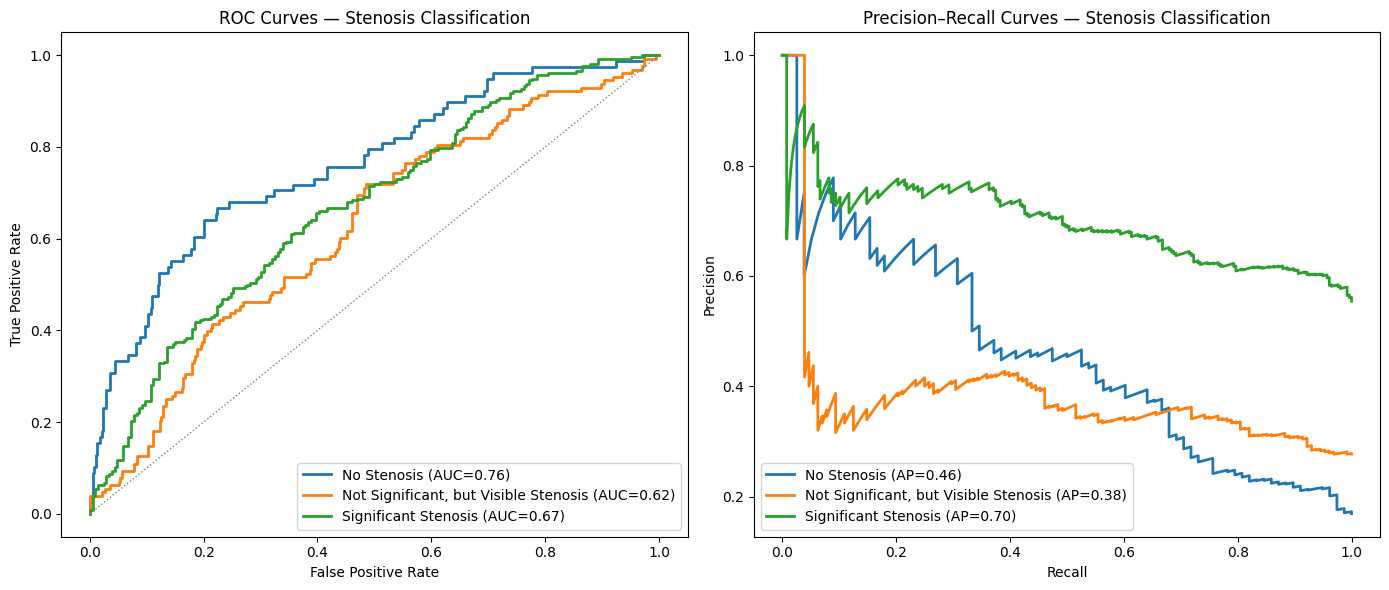

In [ ]:
# Multiclass: ROC & PR curves side-by-side with class names (no micro-average) ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Prepare test data and model
X_test_prepared = pipeline.named_steps["preprocessor"].transform(X_test)
clf = pipeline.named_steps["classifier"]
y_proba = clf.predict_proba(X_test_prepared)
y_pred = clf.predict(X_test_prepared)
classes = clf.classes_

# Define readable medical class names
class_names = {
    0: "No Stenosis",
    1: "Not Significant, but Visible Stenosis",
    2: "Significant Stenosis"
}

# Binarize labels for ROC/PR curves
Y_test_bin = label_binarize(y_test, classes=classes)

# Create a combined figure for ROC and PR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: ROC Curves 
ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{class_names[cls]} (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle=":", lw=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Stenosis Classification")
ax.legend(loc="lower right")

# Right: Precision–Recall Curves
ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, lw=2, label=f"{class_names[cls]} (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves — Stenosis Classification")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


# Feature Importance

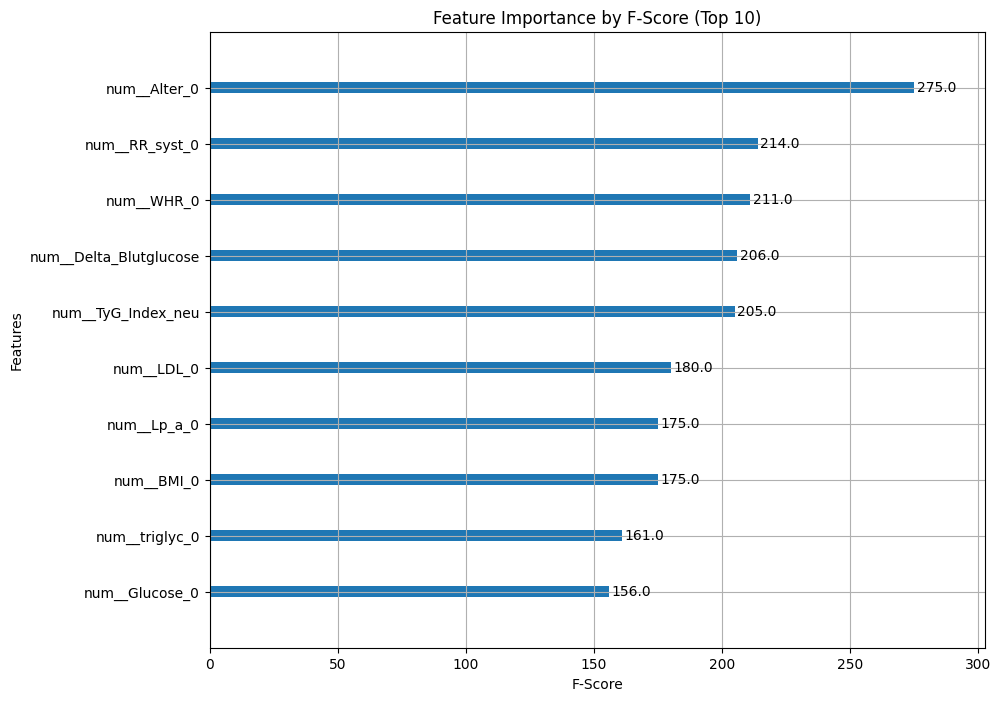

In [152]:
# Find the top 10 important features using XGBoost's plot_importance

# 1. Get the final feature names
feature_names_out = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Extract the trained scikit-learn wrapper
xgb_model = pipeline.named_steps['classifier']

# 3. CRITICAL: Get the underlying Booster object
booster = xgb_model.get_booster()

# 4. CRITICAL: Set the feature names on the Booster object
booster.feature_names = list(feature_names_out)

# 5. Plot the importance using the Booster
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(
    booster,
    ax=ax,
    importance_type='weight',
    xlabel='F-Score',
    max_num_features=10
)
ax.set_title("Feature Importance by F-Score (Top 10)")
plt.show()

Number of features with importance == 1: 129
--- Worst 10 Features by F-Score Importance ---
               Feature  Importance
327   num__NC170OHCerl         1.0
291    num__NC70Cer2Hl         1.0
292      num__NC71Cerl         1.0
184      num__PCaeC381         1.0
294      num__NC80Cerl         1.0
295      num__NC81Cerl         1.0
297  num__NC90OHCer2Hl         1.0
298    num__NC90Cer2Hl         1.0
299      num__NC91Cerl         1.0
186      num__PCaeC384         1.0


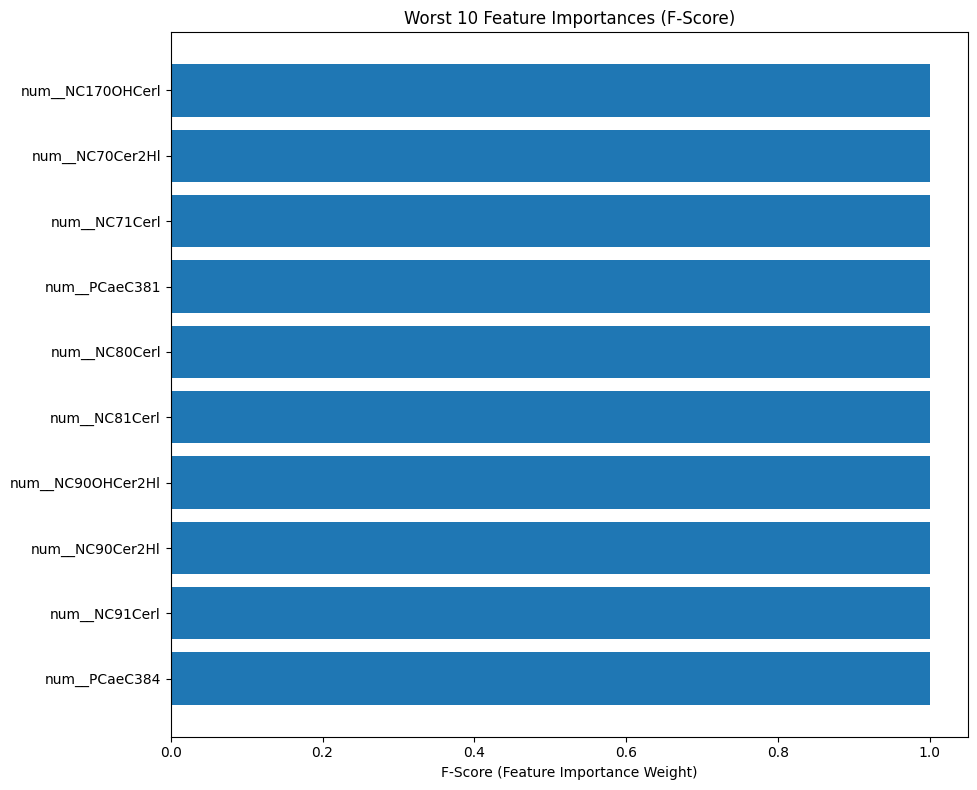

In [153]:
ig, (ax_top, ax_worst) = plt.subplots(1, 2, figsize=(18, 8)) 

# You must also define ax_top even if you don't plot on it, 
# or else you will get an index error later when you try to access ax_worst.
# Let's use a dummy plot on ax_top for now to keep the array structure intact.
ax_top.set_visible(False) # Hide the first axis if you only want to see the second one

# --- Your code snippet starts here ---
importance_dict = booster.get_score(importance_type='weight')
importance_df = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=True)
num_features_with_importance_1 = (importance_df['Importance'] == 1).sum()
print(f"Number of features with importance == 1: {num_features_with_importance_1}")

worst_10_features = importance_df.head(10)

print("--- Worst 10 Features by F-Score Importance ---")
print(worst_10_features)

# Plot Worst 10 on the second subplot
ax_worst.barh(worst_10_features['Feature'], worst_10_features['Importance'])
ax_worst.set_title("Worst 10 Feature Importances (F-Score)")
ax_worst.set_xlabel("F-Score (Feature Importance Weight)")
ax_worst.invert_yaxis()

plt.tight_layout()
plt.show()

# Feature Selection and Model Refinement

In [ ]:
# Feature Selection and Model Refinement 

import numpy as np
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

# Define a full pipeline so feature selection happens inside each CV fold
feature_selector = SelectFromModel(
    estimator=XGBClassifier(
        tree_method="hist",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1
    ),
    threshold="median",
    prefit=False
)

fs_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", feature_selector),
        ("classifier", XGBClassifier(
            tree_method="hist",
            n_estimators=350,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="mlogloss",
            n_jobs=-1
        )),
    ]
)

param_grid = {
    "feature_selection__threshold": ["median", "1.25*mean", "0.75*mean"],
    "feature_selection__estimator__max_depth": [3, 4],
    "classifier__max_depth": [3, 4, 5],
    "classifier__n_estimators": [300, 450],
    "classifier__learning_rate": [0.04, 0.06],
    "classifier__subsample": [0.8, 0.9],
    "classifier__colsample_bytree": [0.7, 0.85]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fit_params = {
    "feature_selection__sample_weight": sample_weights,
    "classifier__sample_weight": sample_weights
}

fs_search = GridSearchCV(
    estimator=fs_pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

fs_search.fit(X_train, y_train, **fit_params)



Fitting 5 folds for each of 288 candidates, totalling 1440 fits


Best parameters: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.04, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8, 'feature_selection__estimator__max_depth': 4, 'feature_selection__threshold': '0.75*mean'}
CV balanced accuracy: 0.5236


NameError: name 'balanced_acc' is not defined

In [155]:
print("Best parameters:", fs_search.best_params_)
print(f"CV balanced accuracy: {fs_search.best_score_:.4f}")

y_pred_fs = fs_search.predict(X_test)
balanced_acc_fs = balanced_accuracy_score(y_test, y_pred_fs)

print(f"Feature-selected balanced accuracy: {balanced_acc_fs:.4f}")

print("\nClassification report (feature-selected model):")
print(classification_report(
    y_test, y_pred_fs,
    target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]
))

Best parameters: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.04, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8, 'feature_selection__estimator__max_depth': 4, 'feature_selection__threshold': '0.75*mean'}
CV balanced accuracy: 0.5236
Feature-selected balanced accuracy: 0.4840

Classification report (feature-selected model):
                          precision    recall  f1-score   support

             No Stenosis       0.40      0.49      0.44        78
Non-significant stenosis       0.34      0.37      0.35       128
    Significant Stenosis       0.67      0.60      0.63       256

                accuracy                           0.52       462
               macro avg       0.47      0.48      0.47       462
            weighted avg       0.53      0.52      0.52       462



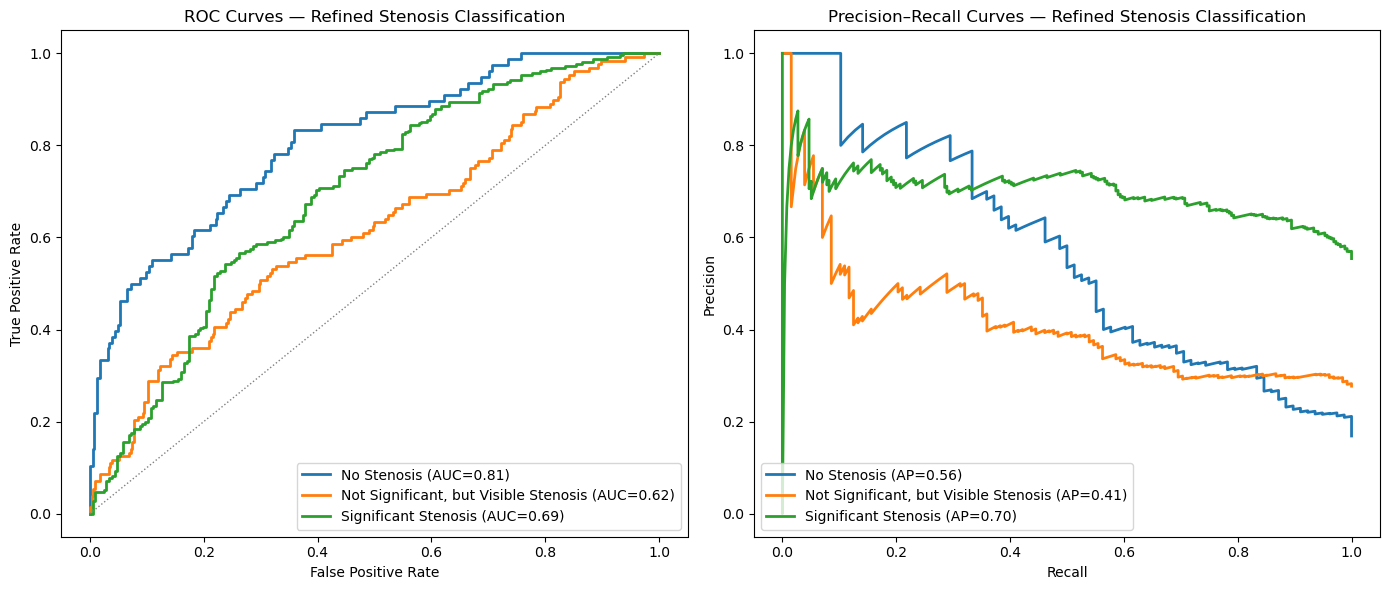

In [ ]:
# ROC & PR Curves for the Refined (Feature-Selected) Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# The refined model & its data
refined_pipeline = fs_search.best_estimator_
y_proba = refined_pipeline.predict_proba(X_test)
y_pred = refined_pipeline.predict(X_test)
classes = refined_pipeline.named_steps["classifier"].classes_

# Define readable medical class names
class_names = {
    0: "No Stenosis",
    1: "Not Significant, but Visible Stenosis",
    2: "Significant Stenosis"
}

# Binarize labels for ROC/PR curves
Y_test_bin = label_binarize(y_test, classes=classes)

# Create a combined figure for ROC and PR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: ROC Curves 
ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{class_names[cls]} (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle=":", lw=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Refined Stenosis Classification")
ax.legend(loc="lower right")

# Right: Precision–Recall Curves
ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, lw=2, label=f"{class_names[cls]} (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves — Refined Stenosis Classification")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()
